In [5]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [6]:
import zipfile

# The 'uploaded' variable was not defined, causing a NameError.
# Since 'archive (2).zip' was uploaded in the previous step,
# we can directly specify its path to proceed.
zip_path = "/content/archive (2).zip"   # Use the known uploaded file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/rafdb")

print("Extraction Done ✅")

Extraction Done ✅


In [7]:
import os

for root, dirs, files in os.walk("/content/rafdb"):
    print(root)

/content/rafdb
/content/rafdb/DATASET
/content/rafdb/DATASET/test
/content/rafdb/DATASET/test/6
/content/rafdb/DATASET/test/5
/content/rafdb/DATASET/test/4
/content/rafdb/DATASET/test/1
/content/rafdb/DATASET/test/2
/content/rafdb/DATASET/test/3
/content/rafdb/DATASET/test/7
/content/rafdb/DATASET/train
/content/rafdb/DATASET/train/6
/content/rafdb/DATASET/train/5
/content/rafdb/DATASET/train/4
/content/rafdb/DATASET/train/1
/content/rafdb/DATASET/train/2
/content/rafdb/DATASET/train/3
/content/rafdb/DATASET/train/7


In [8]:
labels = {}

for file in ["/content/rafdb/train_labels.csv", "/content/rafdb/test_labels.csv"]:
    with open(file, "r") as f:
        next(f)
        for line in f:
            img, label = line.strip().split(',')
            labels[img] = int(label)

In [9]:
import os

csv_files = []
for root, dirs, files in os.walk("/content/rafdb"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

if csv_files:
    print("Found .csv files:")
    for csv_file in csv_files:
        print(csv_file)
else:
    print("No .csv files found in /content/rafdb or its subdirectories.")

Found .csv files:
/content/rafdb/test_labels.csv
/content/rafdb/train_labels.csv


In [10]:
emotion_map = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happy",
    5: "sad",
    6: "angry",
    7: "neutral"
}

In [11]:
import os

base_path = "/content/dataset"

for emotion in emotion_map.values():
    os.makedirs(os.path.join(base_path, emotion), exist_ok=True)

In [12]:
import shutil
import glob # Import glob to find all images

# Find all aligned images recursively under the rafdb directory
all_original_images = glob.glob("/content/rafdb/**/*_aligned.jpg", recursive=True)

# base_path is already defined as "/content/dataset"

for src_path in all_original_images:
    img_name = os.path.basename(src_path) # Get just the filename

    if img_name in labels: # Check if we have a label for this image
        label = labels[img_name]
        emotion = emotion_map[label]

        # Create the destination directory for the emotion if it doesn't exist
        dst_dir = os.path.join(base_path, emotion)
        os.makedirs(dst_dir, exist_ok=True)

        # Construct the full destination path
        dst_path = os.path.join(dst_dir, img_name)

        # Copy the image
        shutil.copy(src_path, dst_path)
    # else:
    #     print(f"Warning: No label found for {img_name}. Skipping.") # Optional: for debugging

In [13]:
from sklearn.model_selection import train_test_split
import glob

all_images = glob.glob(base_path + "/*/*.jpg")

train, test = train_test_split(all_images, test_size=0.2)

# Create folders
os.makedirs("/content/train", exist_ok=True)
os.makedirs("/content/test", exist_ok=True)

# Function to move
def move_images(image_list, target_folder):
    for img_path in image_list:
        label = img_path.split("/")[-2]
        os.makedirs(f"{target_folder}/{label}", exist_ok=True)
        shutil.copy(img_path, f"{target_folder}/{label}")

move_images(train, "/content/train")
move_images(test, "/content/test")

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
BATCH_SIZE = 32

# 🔥 TRAIN (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

# 🔹 VALIDATION (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 🔹 TEST (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train Data
train_data = train_datagen.flow_from_directory(
    "/content/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Data
val_data = val_datagen.flow_from_directory(
    "/content/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Test Data
test_data = test_datagen.flow_from_directory(
    "/content/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 9820 images belonging to 7 classes.
Found 2451 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Bidirectional, LSTM

cnn_model = Sequential()

# CNN
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128, (3,3), activation='relu'))  # NEW
cnn_model.add(MaxPooling2D(2,2))

from tensorflow.keras.layers import Dropout
cnn_model.add(Dropout(0.5))

cnn_model.add(Flatten())

# Convert to sequence for BiLSTM
cnn_model.add(Reshape((64, -1)))

# BiLSTM
cnn_model.add(Bidirectional(LSTM(128)))
# Dense
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(train_data.num_classes, activation='softmax'))

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [18]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.3912 - loss: 1.6271 - val_accuracy: 0.4035 - val_loss: 1.5603
Epoch 2/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.3962 - loss: 1.5686 - val_accuracy: 0.4178 - val_loss: 1.5089
Epoch 3/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.4118 - loss: 1.5323 - val_accuracy: 0.4455 - val_loss: 1.4515
Epoch 4/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.4794 - loss: 1.4050 - val_accuracy: 0.5426 - val_loss: 1.2588
Epoch 5/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.5349 - loss: 1.2874 - val_accuracy: 0.5655 - val_loss: 1.1938
Epoch 6/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.5517 - loss: 1.2297 - val_accuracy: 0.5753 - val_loss: 1.1327
Epoch 7/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.5672 - loss: 1.1857 - val_accuracy: 0.6006 - val_loss: 1.0962
Epoch 8/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.5803 - loss: 1.1444 - 

In [19]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Training Accuracy:", train_acc*100)
print("Validation Accuracy:", val_acc*100)

Training Accuracy: 67.80040860176086
Validation Accuracy: 69.31864619255066


In [20]:
test_loss, test_acc = cnn_model.evaluate(test_data)

print("Test Accuracy:", test_acc*100)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6962 - loss: 0.8603
Test Accuracy: 69.62190270423889


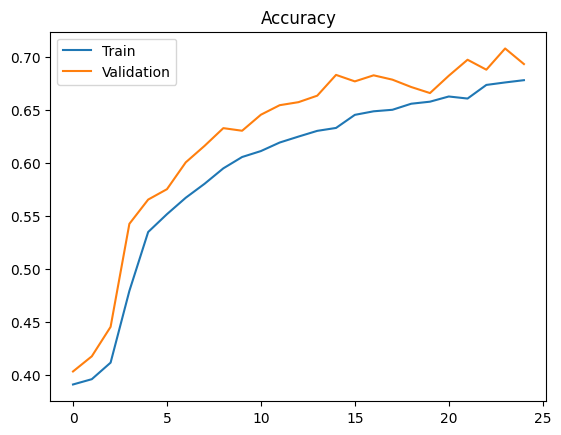

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

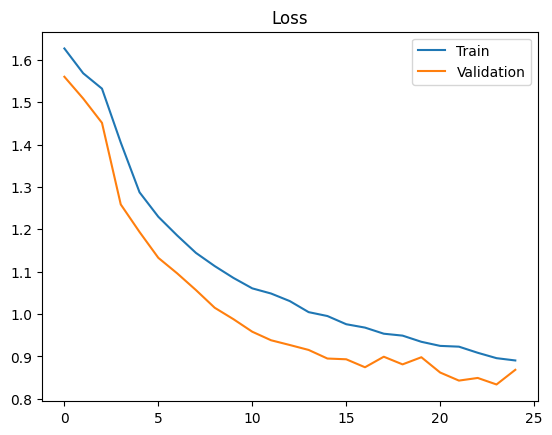

In [22]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

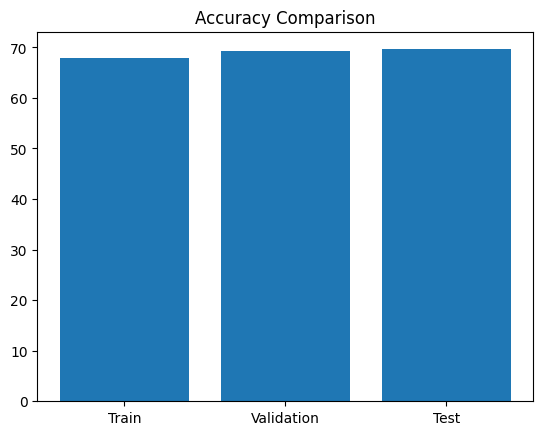

In [23]:
labels = ['Train','Validation','Test']
values = [train_acc*100, val_acc*100, test_acc*100]

plt.figure()
plt.bar(labels, values)
plt.title("Accuracy Comparison")
plt.show()

In [24]:
import glob

images = glob.glob("/content/test/happy/*.jpg")

print(images[0])

/content/test/happy/train_02110_aligned.jpg


In [25]:
import cv2

# Original image
original = cv2.imread(images[0], cv2.IMREAD_GRAYSCALE)

# Processed image (what your model does)
processed = cv2.resize(original, (48,48))

In [26]:
processed = cv2.resize(processed, (original.shape[1], original.shape[0]))

In [27]:
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import numpy as np

mse = mean_squared_error(original, processed)
psnr = peak_signal_noise_ratio(original, processed)
ssim = structural_similarity(original, processed)
mae = np.mean(np.abs(original - processed))

print("MSE:", mse)
print("PSNR:", psnr)
print("SSIM:", ssim)
print("MAE:", mae)

MSE: 5.236
PSNR: 40.94080722989192
SSIM: 0.9845718164058858
MAE: 66.6536


Saving 657ecf33c60cc9ea1176f4f1_Autistic (44).jpg to 657ecf33c60cc9ea1176f4f1_Autistic (44) (2).jpg
Processing: 657ecf33c60cc9ea1176f4f1_Autistic (44) (2).jpg
Faces detected: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Emotion: happy


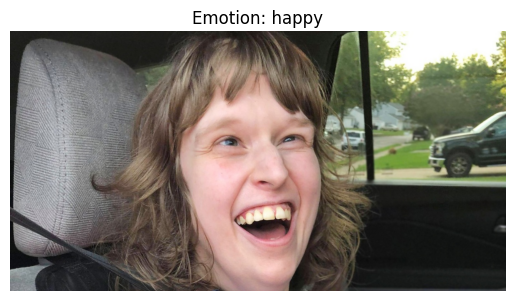

In [33]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

emotion_labels = {
    0: "surprise",
    1: "fear",
    2: "disgust",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "neutral"
}

for file_name in uploaded.keys():
    print("Processing:", file_name)  # ✅ debug line

    img = cv2.imread(file_name)

    if img is None:
        print("Image not loaded ❌")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    print("Faces detected:", len(faces))  # ✅ debug line

    if len(faces) == 0:
        print("No face detected ❌")

        # Try predicting whole image (fallback)
        img_resized = cv2.resize(img, (48,48))
        img_resized = img_resized / 255.0
        img_input = np.reshape(img_resized, (1,48,48,3))

        prediction = cnn_model.predict(img_input)
        emotion = np.argmax(prediction)

        print("Predicted Emotion (full image):", emotion_labels[emotion])
        continue

    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]

        face = cv2.resize(face, (48,48))
        face = face / 255.0
        face = np.reshape(face, (1,48,48,3))

        prediction = cnn_model.predict(face)
        emotion = np.argmax(prediction)

        print("Predicted Emotion:", emotion_labels[emotion])

        # Show image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"Emotion: {emotion_labels[emotion]}")
        plt.axis('off')
        plt.show()

Saving Screenshot 2026-04-05 142508.png to Screenshot 2026-04-05 142508.png
Processing: Screenshot 2026-04-05 142508.png
Faces detected: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Emotion: disgust


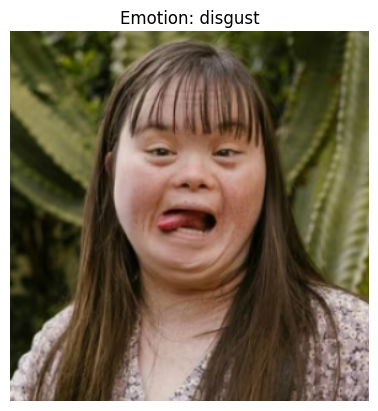

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

emotion_labels = {
    0: "surprise",
    1: "fear",
    2: "disgust",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "neutral"
}

for file_name in uploaded.keys():
    print("Processing:", file_name)  # ✅ debug line

    img = cv2.imread(file_name)

    if img is None:
        print("Image not loaded ❌")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    print("Faces detected:", len(faces))  # ✅ debug line

    if len(faces) == 0:
        print("No face detected ❌")

        # Try predicting whole image (fallback)
        img_resized = cv2.resize(img, (48,48))
        img_resized = img_resized / 255.0
        img_input = np.reshape(img_resized, (1,48,48,3))

        prediction = cnn_model.predict(img_input)
        emotion = np.argmax(prediction)

        print("Predicted Emotion (full image):", emotion_labels[emotion])
        continue

    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]

        face = cv2.resize(face, (48,48))
        face = face / 255.0
        face = np.reshape(face, (1,48,48,3))

        prediction = cnn_model.predict(face)
        emotion = np.argmax(prediction)

        print("Predicted Emotion:", emotion_labels[emotion])

        # Show image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"Emotion: {emotion_labels[emotion]}")
        plt.axis('off')
        plt.show()

In [35]:
cnn_model.save("model.h5")